# Detección de mensajes SMS spam mediante fine-tuning de FLAN-T5-small

**Redes Neuronales y Aprendizaje Profundo** · Proyecto de fin de parcial (Segundo Parcial)

**Integrantes:** [completar]
**Fecha de entrega:** [completar]
**Repositorio:** [enlace de GitHub]

# 1. Paper seleccionado y planteamiento del problema

## 1.1 Datos del paper

**Título:** *Spam-T5: Benchmarking Large Language Models for Few-Shot Email Spam Detection*  
**Autores:** Maxime Labonne y Sean Moran  
**Año:** 2023  
**Fuente:** arXiv  
**Tema principal:** Uso de FLAN-T5 para la detección de mensajes spam.

## 1.2 Resumen del paper

El artículo *Spam-T5: Benchmarking Large Language Models for Few-Shot Email Spam Detection*, de Maxime Labonne y Sean Moran (2023), estudia si los modelos de lenguaje grandes pueden detectar mensajes spam de forma efectiva, incluso cuando se dispone de pocos ejemplos etiquetados. Este problema es importante porque los filtros de spam deben enfrentarse al desbalance entre mensajes legítimos y fraudulentos, a los cambios constantes en la forma de redactar el spam y a las estrategias utilizadas para evitar los sistemas de detección.

Los autores comparan seis modelos tradicionales de aprendizaje automático —Naive Bayes, regresión logística, KNN, SVM, XGBoost y LightGBM— con tres modelos de lenguaje: RoBERTa, SetFit y FLAN-T5. Para realizar los experimentos utilizaron cuatro conjuntos de datos públicos: Ling-Spam, SMS Spam Collection, SpamAssassin y Enron. También evaluaron el comportamiento de los modelos con el conjunto completo de entrenamiento y con cantidades reducidas de 4, 8, 16, 32, 64, 128 y 256 ejemplos.

El principal aporte del estudio es Spam-T5, una versión de FLAN-T5 ajustada específicamente para clasificar mensajes como ham o spam. Para ello, los autores agregaron la instrucción “classify as ham or spam:” al inicio de cada texto y entrenaron el modelo para generar directamente una de esas dos etiquetas.

Los resultados muestran que Spam-T5 obtuvo el mejor rendimiento general y destacó especialmente en los escenarios con muy pocos ejemplos. Con los conjuntos completos alcanzó un F1 promedio de 0.9742, mientras que al considerar todos los tamaños de entrenamiento obtuvo el mejor promedio global, con 0.7498. El artículo concluye que FLAN-T5 puede ser una alternativa eficaz para la detección de spam, aunque su entrenamiento y uso requieren más recursos computacionales que los métodos tradicionales.

## 1.3 Relación del paper con el proyecto

Se escogió este paper porque se relaciona directamente con el tema desarrollado en el proyecto: la clasificación de mensajes como ham o spam mediante FLAN-T5. Además, uno de los conjuntos de datos utilizados por los autores es SMS Spam Collection, que también es el dataset empleado en este notebook.

El artículo sirve como referencia para conocer cómo se puede adaptar FLAN-T5 a una tarea de clasificación. Primero se añade una instrucción al mensaje y luego se realiza el fine-tuning para que el modelo aprenda a generar una de las dos etiquetas posibles.

En el paper se trabajó principalmente con FLAN-T5-base. En este proyecto se utilizará FLAN-T5-small, ya que es una versión más ligera y adecuada para ejecutarse en Google Colab con recursos limitados. Por esta razón, el proyecto no busca reproducir exactamente todos los experimentos del artículo, sino aplicar su idea principal al mismo problema.

Primero se evaluará el modelo sin entrenamiento específico mediante zero-shot prompting. Después se realizará el fine-tuning y se compararán los resultados para comprobar si la adaptación mejora la clasificación de los mensajes.

## 1.4 Referencia bibliográfica

Labonne, M., & Moran, S. (2023). *Spam-T5: Benchmarking large language models for few-shot email spam detection* [Preprint]. arXiv. https://arxiv.org/pdf/2304.01238

## 1.5 Planteamiento del proyecto

**Descripción del problema.** La detección de spam es un problema de clasificación binaria de texto caracterizado por el desbalance de clases y por la evolución constante del lenguaje usado por los emisores de spam. Los enfoques tradicionales requieren grandes cantidades de datos etiquetados; los modelos de lenguaje pre-entrenados permiten adaptar conocimiento lingüístico general a esta tarea con un entrenamiento relativamente corto.

**Pregunta de investigación.** ¿En qué medida el fine-tuning de FLAN-T5-small sobre el dataset SMS Spam Collection mejora la clasificación de mensajes como *ham* o *spam*, en comparación con el mismo modelo evaluado en zero-shot?

**Objetivo general.** Adaptar el modelo pre-entrenado FLAN-T5-small a la detección de spam en mensajes SMS mediante fine-tuning completo, y cuantificar la mejora respecto al modelo base sin adaptar.

**Objetivos específicos.**
1. Preparar y analizar el dataset SMS Spam Collection (limpieza, EDA y división estratificada).
2. Establecer un *baseline* evaluando FLAN-T5-small en zero-shot sobre el conjunto de prueba.
3. Aplicar fine-tuning texto-a-texto siguiendo la estrategia del paper de referencia.
4. Comparar ambos modelos con las mismas métricas (accuracy, precision, recall, F1) sobre el mismo split de prueba.
5. Analizar críticamente los resultados, los errores restantes y las limitaciones del enfoque.

**Hipótesis.** El modelo fine-tuneado superará de forma sustancial al modelo base zero-shot en F1 de la clase spam y en F1 macro, dado que el ajuste con ejemplos etiquetados corrige la incapacidad del modelo base para distinguir las clases a partir únicamente de la instrucción del prompt.

## 1.6 Resultados reportados por el paper de referencia

Resultados del paper para el dataset **SMS Spam Collection** con el conjunto de entrenamiento completo (Tabla 3 del paper):

| Modelo | F1 | Precision | Recall |
|---|---|---|---|
| Naive Bayes | 0.89 | 0.82 | 0.98 |
| SVM | 0.90 | 0.83 | 0.98 |
| RoBERTa | 0.95 | 0.97 | 0.92 |
| SetFit | 0.96 | 0.97 | 0.95 |
| **Spam-T5 (FLAN-T5-base fine-tuneado)** | **0.95** | **0.97** | **0.94** |

Adicionalmente, promediando los cuatro datasets, Spam-T5 alcanza el mejor F1 con entrenamiento completo (0.9742) y el mejor promedio global considerando todos los tamaños de entrenamiento few-shot (0.7498). Estos valores sirven como referencia para la comparación de la sección 6.4.

# 2. Dataset y análisis exploratorio de datos

En esta sección se descarga, revisa y prepara el dataset SMS Spam Collection.

**Justificación del dataset.** Se eligió este conjunto porque (1) es uno de los cuatro datasets evaluados en el paper de referencia, lo que permite comparar resultados de forma directa; (2) es público y se descarga con código desde Hugging Face, cumpliendo las normas de entrega; (3) presenta el desbalance de clases característico del problema real (~87 % ham / ~13 % spam), lo que exige analizar métricas más allá del accuracy; y (4) su tamaño (~5,500 mensajes cortos) hace viable el fine-tuning completo en Google Colab con recursos limitados.

**Instalación e importación de bibliotecas**

In [ ]:
!pip install -q datasets pandas scikit-learn matplotlib

In [ ]:
from datasets import load_dataset, Dataset, DatasetDict
from sklearn.model_selection import train_test_split

import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
pd.set_option("display.max_colwidth", 200)

Bibliotecas importadas correctamente.


## 2.1 Descarga del dataset

Se utilizó el conjunto público SMS Spam Collection, disponible en Hugging Face con el identificador `ucirvine/sms_spam`.

In [ ]:
ds = load_dataset("ucirvine/sms_spam")
print(ds)

README.md:   0%|          | 0.00/4.98k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  359kB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5574 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sms', 'label'],
        num_rows: 5574
    })
})


## 2.2 Revisar columnas y etiquetas

El dataset contiene dos variables principales: `sms` (texto del mensaje) y `label` (0 = ham, mensaje legítimo; 1 = spam, mensaje no deseado).

In [ ]:
datos = ds["train"]

print("Características del dataset:")
print(datos.features)

print("\nNombres de las clases:")
print(datos.features["label"].names)

Características del dataset:
{'sms': Value('string'), 'label': ClassLabel(names=['ham', 'spam'])}

Nombres de las clases:
['ham', 'spam']


**Conversión a Pandas**

In [ ]:
df = datos.to_pandas()

nombres_clases = datos.features["label"].names
df["label_text"] = df["label"].apply(lambda etiqueta: nombres_clases[int(etiqueta)])

display(df.head())

Dataset convertido a Pandas.


,sms,label,label_text
0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...\n",0,ham
1,Ok lar... Joking wif u oni...\n,0,ham
2,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's\n,1,spam
3,U dun say so early hor... U c already then say...\n,0,ham
4,"Nah I don't think he goes to usf, he lives around here though\n",0,ham


## 2.3 Primeros registros y dimensiones

Revisión de los primeros registros, los nombres de las columnas, sus dimensiones y sus tipos de datos para comprobar que la descarga se realizó correctamente.

In [ ]:
print("Primeros cinco registros:")
display(df.head())

Primeros cinco registros:


,sms,label,label_text
0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...\n",0,ham
1,Ok lar... Joking wif u oni...\n,0,ham
2,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's\n,1,spam
3,U dun say so early hor... U c already then say...\n,0,ham
4,"Nah I don't think he goes to usf, he lives around here though\n",0,ham


In [ ]:
print("Dimensiones del dataset:", df.shape)
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

print("\nColumnas:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

Dimensiones del dataset: (5574, 3)
Número de filas: 5574
Número de columnas: 3

Columnas:
['sms', 'label', 'label_text']

Tipos de datos:
sms           object
label          int64
label_text    object
dtype: object


## 2.4 Revisar nulos, vacíos y duplicados

Se comprueba la existencia de valores nulos, mensajes vacíos y mensajes duplicados.

In [ ]:
print("Valores nulos por columna:")
print(df.isnull().sum())

mensajes_vacios = (df["sms"].fillna("").astype(str).str.strip().eq("").sum())

duplicados_exactos = df.duplicated(subset=["sms"]).sum()

print("\nMensajes vacíos:", mensajes_vacios)
print("Mensajes duplicados:", duplicados_exactos)

Valores nulos por columna:
sms           0
label         0
label_text    0
dtype: int64

Mensajes vacíos: 0
Mensajes duplicados: 403


## 2.5 Comprobar conflictos en las etiquetas

Se verifica si existen mensajes idénticos con etiquetas diferentes.

In [ ]:
mensajes_con_conflicto = (df.groupby("sms")["label"].nunique().gt(1).sum())

print("Mensajes repetidos con etiquetas diferentes:",mensajes_con_conflicto)

Mensajes repetidos con etiquetas diferentes: 0


## 2.6 Limpieza del dataset

Se eliminan espacios innecesarios, textos vacíos y mensajes duplicados, conservando una copia del dataset original.

In [ ]:
df_limpio = df.copy()
cantidad_inicial = len(df_limpio)

df_limpio["sms"] = df_limpio["sms"].astype("string").str.strip()
df_limpio = df_limpio.dropna(subset=["sms", "label"])
df_limpio = df_limpio[df_limpio["sms"] != ""].copy()

duplicados_eliminados = df_limpio.duplicated(subset=["sms"]).sum()
df_limpio = df_limpio.drop_duplicates(subset=["sms"], keep="first").reset_index(drop=True)

df_limpio["label"] = df_limpio["label"].astype(int)
df_limpio["label_text"] = df_limpio["label"].map({0: "ham", 1: "spam"})

cantidad_final = len(df_limpio)

print("Cantidad inicial:", cantidad_inicial)
print("Duplicados eliminados:", duplicados_eliminados)
print("Cantidad final:", cantidad_final)
print("Registros eliminados:", cantidad_inicial - cantidad_final)

Cantidad inicial: 5574
Duplicados eliminados: 414
Cantidad final: 5160
Registros eliminados: 414


**Verificación posterior a la limpieza**

In [ ]:
print("Valores nulos después de la limpieza:")
print(df_limpio.isnull().sum())

print("\nMensajes vacíos después de la limpieza:")
print(df_limpio["sms"].astype(str).str.strip().eq("").sum())

print("\nDuplicados después de la limpieza:")
print(df_limpio.duplicated(subset=["sms"]).sum())

Valores nulos después de la limpieza:
sms           0
label         0
label_text    0
dtype: int64

Mensajes vacíos después de la limpieza:
0

Duplicados después de la limpieza:
0


## 2.7 Conteo y porcentaje de cada clase

In [ ]:
conteo_clases = (df_limpio["label_text"].value_counts())

porcentaje_clases = (df_limpio["label_text"].value_counts(normalize=True).mul(100).round(2))

resumen_clases = pd.DataFrame({"cantidad": conteo_clases,"porcentaje": porcentaje_clases})

resumen_clases.index.name = "clase"

display(resumen_clases)

,cantidad,porcentaje
clase,,
ham,4518,87.56
spam,642,12.44


## 2.8 Gráfica de distribución de clases

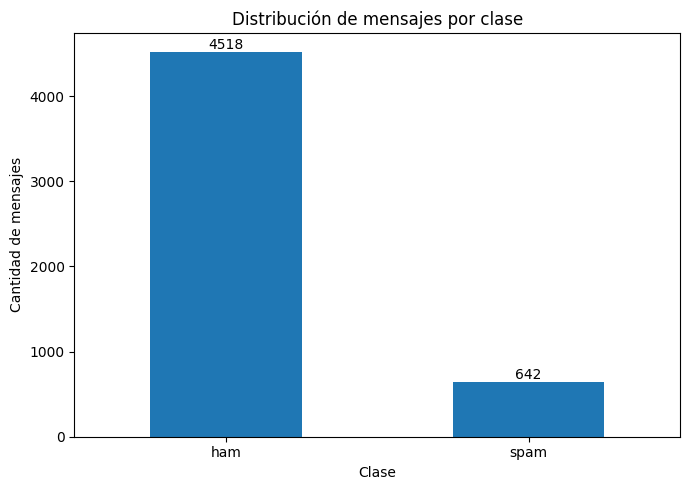

La gráfica evidencia que la clase 'ham' contiene una cantidad mayor de mensajes que la clase 'spam'.


In [ ]:
plt.figure(figsize=(7, 5))

grafica = conteo_clases.plot(
    kind="bar"
)

plt.title("Distribución de mensajes por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad de mensajes")
plt.xticks(rotation=0)

for contenedor in grafica.containers:
    grafica.bar_label(contenedor)

plt.tight_layout()
plt.show()

print(
    "La gráfica evidencia que la clase 'ham' contiene una cantidad mayor "
    "de mensajes que la clase 'spam'."
)

## 2.9 Longitud de los mensajes

Permite comprobar si existen diferencias entre los mensajes legítimos y los mensajes spam.

In [ ]:
df_limpio["num_caracteres"] = df_limpio["sms"].str.len()
df_limpio["num_palabras"] = df_limpio["sms"].str.split().str.len()

display(df_limpio[["sms", "label_text", "num_caracteres", "num_palabras"]].head())

,sms,label_text,num_caracteres,num_palabras
0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",ham,111,20
1,Ok lar... Joking wif u oni...,ham,29,6
2,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,spam,155,28
3,U dun say so early hor... U c already then say...,ham,49,11
4,"Nah I don't think he goes to usf, he lives around here though",ham,61,13


## 2.10 Longitud promedio por clase

In [ ]:
resumen_longitudes = (
    df_limpio
    .groupby("label_text")[["num_caracteres", "num_palabras"]]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

display(resumen_longitudes)

num_caracteres                 num_palabras                
                     mean median min  max         mean median min  max
label_text                                                            
ham                 70.86   53.0   2  910        14.23   11.0   1  171
spam               137.41  148.0  13  223        23.70   25.0   2   35

## 2.11 Histograma de longitudes

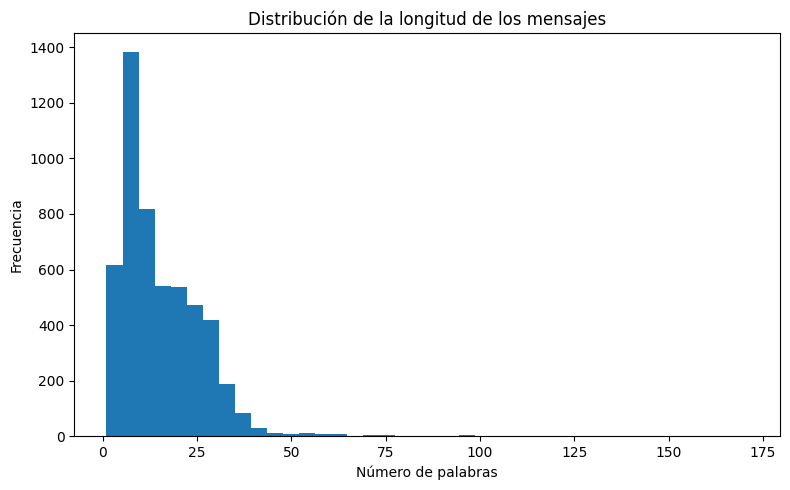

La distribución no es simétrica debido a la presencia de mensajes largos, por lo que la mayoría se concentra en longitudes cortas, mientras que una cantidad menor presenta una extensión mayor.


In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_limpio["num_palabras"],
    bins=40
)

plt.title("Distribución de la longitud de los mensajes")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

print(
    "La distribución no es simétrica debido a la presencia de mensajes largos, "
    "por lo que la mayoría se concentra en longitudes cortas, mientras que una "
    "cantidad menor presenta una extensión mayor."
)

## 2.12 Comparación de longitud entre spam y ham

<Figure size 700x500 with 0 Axes>

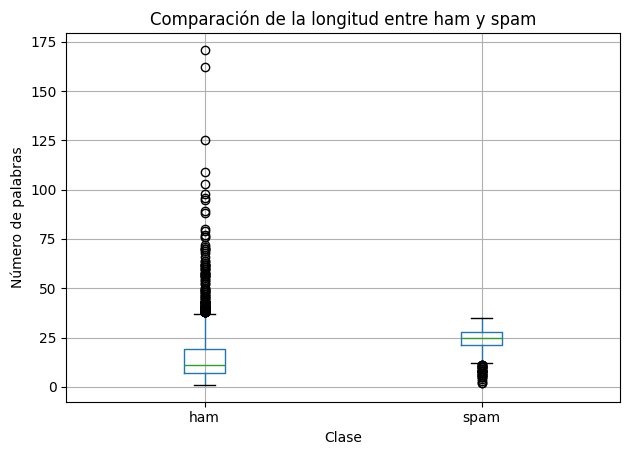

Las diferencias observadas sugieren que la cantidad de palabras puede aportar información para distinguir entre mensajes legítimos y spam, aunque no debe utilizarse como único criterio de clasificación.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
df_limpio.boxplot(column="num_palabras", by="label_text", ax=ax)

plt.title("Comparación de la longitud entre ham y spam")
plt.suptitle("")
plt.xlabel("Clase")
plt.ylabel("Número de palabras")
plt.tight_layout()
plt.show()

print(
    "Las diferencias observadas sugieren que la cantidad de palabras puede "
    "aportar información para distinguir entre mensajes legítimos y spam, "
    "aunque no debe utilizarse como único criterio de clasificación."
)

## 2.13 Ejemplos de ambas clases

In [ ]:
ejemplos_ham = (
    df_limpio[df_limpio["label_text"] == "ham"][["sms", "label_text"]]
    .sample(n=5, random_state=SEED)
)

ejemplos_spam = (
    df_limpio[df_limpio["label_text"] == "spam"][["sms", "label_text"]]
    .sample(n=5, random_state=SEED)
)

print("Ejemplos de mensajes ham:")
display(ejemplos_ham)

print("\nEjemplos de mensajes spam:")
display(ejemplos_spam)

Ejemplos de mensajes ham:


,sms,label_text
4439,Me too! Have a lovely night xxx,ham
850,"Well am officially in a philosophical hole, so if u wanna call am at home ready to be saved!",ham
235,"New Theory: Argument wins d SITUATION, but loses the PERSON. So dont argue with ur friends just.. . . . kick them &amp; say, I'm always correct.!",ham
2042,Do you know when the result.,ham
3343,SO IS TH GOWER MATE WHICH IS WHERE I AM!?! HOW R U MAN? ALL IS GOOD IN WALES ILL B BACK MORROW. C U THIS WK? WHO WAS THE MSG 4?  RANDOM!,ham



Ejemplos de mensajes spam:


,sms,label_text
600,22 days to kick off! For Euro2004 U will be kept up to date with the latest news and results daily. To be removed send GET TXT STOP to 83222,spam
1336,Double Mins & Double Txt & 1/2 price Linerental on Latest Orange Bluetooth mobiles. Call MobileUpd8 for the very latest offers. 08000839402 or call2optout/LF56,spam
3753,Bored housewives! Chat n date now! 0871750.77.11! BT-national rate 10p/min only from landlines!,spam
4909,Urgent! Please call 09061213237 from landline. £5000 cash or a luxury 4* Canary Islands Holiday await collection. T&Cs SAE PO Box 177. M227XY. 150ppm. 16+,spam
509,Your credits have been topped up for http://www.bubbletext.com Your renewal Pin is tgxxrz,spam


## 2.14 División estratificada del dataset

Se divide el dataset limpio en tres particiones (70 % entrenamiento, 15 % validación y 15 % prueba), manteniendo la proporción de clases mediante estratificación.

In [ ]:
df_modelo = df_limpio[["sms", "label", "label_text"]].copy()
print("Registros disponibles para la división:", len(df_modelo))

Registros disponibles para la división: 5160


**Primera división: 70 % y 30 %**

In [ ]:
df_train, df_temporal = train_test_split(
    df_modelo,
    test_size=0.30,
    random_state=SEED,
    stratify=df_modelo["label"]
)

**Segunda división del 30 % restante: 15 % validación y 15 % prueba**

In [ ]:
df_validation, df_test = train_test_split(
    df_temporal,
    test_size=0.50,
    random_state=SEED,
    stratify=df_temporal["label"]
)

# Reiniciar los índices
df_train = df_train.reset_index(drop=True)
df_validation = df_validation.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("Entrenamiento:", len(df_train))
print("Validación:", len(df_validation))
print("Prueba:", len(df_test))

print(
    "Total:",
    len(df_train) +
    len(df_validation) +
    len(df_test)
)

Entrenamiento: 3612
Validación: 774
Prueba: 774
Total: 5160


## 2.15 Comprobación de la estratificación

In [ ]:
def obtener_distribucion(nombre, dataframe):
    conteo = dataframe["label_text"].value_counts()
    porcentaje = (
        dataframe["label_text"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    resultado = pd.DataFrame({
        "split": nombre,
        "clase": conteo.index,
        "cantidad": conteo.values,
        "porcentaje": porcentaje.loc[conteo.index].values
    })

    return resultado


distribucion_splits = pd.concat(
    [
        obtener_distribucion("train", df_train),
        obtener_distribucion("validation", df_validation),
        obtener_distribucion("test", df_test)
    ],
    ignore_index=True
)

display(distribucion_splits)

,split,clase,cantidad,porcentaje
0,train,ham,3163,87.57
1,train,spam,449,12.43
2,validation,ham,677,87.47
3,validation,spam,97,12.53
4,test,ham,678,87.60
5,test,spam,96,12.40


## 2.16 Conversión al formato de Hugging Face

In [ ]:
dataset_final = DatasetDict({
    "train": Dataset.from_pandas(df_train[["sms", "label", "label_text"]], preserve_index=False),
    "validation": Dataset.from_pandas(df_validation[["sms", "label", "label_text"]], preserve_index=False),
    "test": Dataset.from_pandas(df_test[["sms", "label", "label_text"]], preserve_index=False),
})

print(dataset_final)

DatasetDict({
    train: Dataset({
        features: ['sms', 'label', 'label_text'],
        num_rows: 3612
    })
    validation: Dataset({
        features: ['sms', 'label', 'label_text'],
        num_rows: 774
    })
    test: Dataset({
        features: ['sms', 'label', 'label_text'],
        num_rows: 774
    })
})


## 2.17 Resumen del preprocesamiento

In [ ]:
cantidad_ham = (df_limpio["label_text"] == "ham").sum()
cantidad_spam = (df_limpio["label_text"] == "spam").sum()
porcentaje_ham = cantidad_ham / len(df_limpio) * 100
porcentaje_spam = cantidad_spam / len(df_limpio) * 100

resumen_preprocesamiento = f"""
El dataset original contenía {cantidad_inicial} mensajes SMS.
Durante el preprocesamiento se eliminaron {duplicados_eliminados}
mensajes duplicados, además de los posibles valores nulos o textos
vacíos. Después de la limpieza quedaron {cantidad_final} registros.

La clase ham contiene {cantidad_ham} mensajes
({porcentaje_ham:.2f} %), mientras que la clase spam contiene
{cantidad_spam} mensajes ({porcentaje_spam:.2f} %).

El dataset limpio se dividió de forma estratificada en
{len(df_train)} registros de entrenamiento,
{len(df_validation)} de validación y
{len(df_test)} de prueba.
"""

print(resumen_preprocesamiento)


El dataset original contenía 5574 mensajes SMS.
Durante el preprocesamiento se eliminaron 414
mensajes duplicados, además de los posibles valores nulos o textos
vacíos. Después de la limpieza quedaron 5160 registros.

La clase ham contiene 4518 mensajes
(87.56 %), mientras que la clase spam contiene
642 mensajes (12.44 %).

El dataset limpio se dividió de forma estratificada en
3612 registros de entrenamiento,
774 de validación y
774 de prueba.



# 3. Modelo base (zero-shot) con FLAN-T5-small

Se evalúa `google/flan-t5-small` **sin ningún entrenamiento adicional** sobre el conjunto de prueba. Estas métricas constituyen el *baseline* obligatorio ("antes") contra el cual se comparará el modelo fine-tuneado.

In [ ]:
!pip install -q transformers accelerate sentencepiece evaluate ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00


In [ ]:
import time

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

torch.manual_seed(SEED)

DISPOSITIVO = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo utilizado:", DISPOSITIVO)

Dispositivo utilizado: cuda


## 3.1 Carga del modelo y del tokenizador

In [ ]:
NOMBRE_MODELO = "google/flan-t5-small"

tokenizer = AutoTokenizer.from_pretrained(NOMBRE_MODELO)
modelo_base = AutoModelForSeq2SeqLM.from_pretrained(NOMBRE_MODELO).to(DISPOSITIVO)
modelo_base.eval()

print("Modelo base cargado:", NOMBRE_MODELO)
print("Número de parámetros:", sum(p.numel() for p in modelo_base.parameters()))

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Modelo base cargado: google/flan-t5-small
Número de parámetros: 76961152


## 3.2 Diseño del prompt de clasificación

El prompt sigue la estrategia del paper de referencia: una instrucción explícita que indica la tarea y restringe la salida a las dos etiquetas posibles (`spam` o `ham`), lo que facilita la normalización posterior de las respuestas generadas.

In [ ]:
def construir_prompt(mensaje):
    return (
        "Classify the following SMS message as spam or ham:\n"
        f'"{mensaje}"\n'
        "Answer only spam or ham:"
    )

print(construir_prompt("Congratulations! You have won a free prize."))

Classify the following SMS message as spam or ham:
"Congratulations! You have won a free prize."
Answer only spam or ham:


## 3.3 Función de predicción por lotes

In [ ]:
def predecir_lote(mensajes, modelo, tokenizador, batch_size=32, max_new_tokens=5):
    modelo.eval()
    predicciones_texto = []

    for inicio in range(0, len(mensajes), batch_size):
        lote = mensajes[inicio: inicio + batch_size]
        prompts = [construir_prompt(m) for m in lote]

        entradas = tokenizador(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=128,
        ).to(DISPOSITIVO)

        with torch.no_grad():
            salidas = modelo.generate(**entradas, max_new_tokens=max_new_tokens)

        predicciones_texto.extend(
            tokenizador.batch_decode(salidas, skip_special_tokens=True)
        )

    return predicciones_texto

## 3.4 Normalización de las respuestas generadas

Cada respuesta se clasifica como `spam`, `ham` o `invalid` cuando el texto generado no corresponde de forma inequívoca a ninguna de las dos etiquetas.

In [ ]:
def normalizar_respuesta(texto):
    texto_normalizado = texto.strip().lower()

    contiene_spam = "spam" in texto_normalizado
    contiene_ham = "ham" in texto_normalizado

    if contiene_spam and not contiene_ham:
        return "spam"
    if contiene_ham and not contiene_spam:
        return "ham"
    return "invalid"


## 3.5 Evaluación zero-shot sobre el conjunto de prueba

In [ ]:
mensajes_test = df_test["sms"].tolist()
etiquetas_reales = df_test["label_text"].tolist()

inicio_tiempo = time.time()
respuestas_crudas = predecir_lote(mensajes_test, modelo_base, tokenizer)
tiempo_zero_shot = time.time() - inicio_tiempo

predicciones_zero_shot = [normalizar_respuesta(r) for r in respuestas_crudas]

print(f"Tiempo de inferencia zero-shot: {tiempo_zero_shot:.2f} segundos")
print("Ejemplo de respuestas crudas:", respuestas_crudas[:10])
print("Ejemplo de respuestas normalizadas:", predicciones_zero_shot[:10])

Tiempo de inferencia zero-shot: 5.67 segundos
Ejemplo de respuestas crudas: ['spam', 'spam', 'spam', 'spam', 'spam', 'spam', 'spam', 'spam', 'spam', 'spam']
Ejemplo de respuestas normalizadas: ['spam', 'spam', 'spam', 'spam', 'spam', 'spam', 'spam', 'spam', 'spam', 'spam']


## 3.6 Registro de respuestas inválidas

In [ ]:
cantidad_invalidas_zero_shot = predicciones_zero_shot.count("invalid")
porcentaje_invalidas_zero_shot = (
    cantidad_invalidas_zero_shot / len(predicciones_zero_shot) * 100
)

print(
    "Respuestas inválidas (zero-shot):",
    cantidad_invalidas_zero_shot,
    f"({porcentaje_invalidas_zero_shot:.2f} %)"
)

Respuestas inválidas (zero-shot): 0 (0.00 %)


## 3.7 Métricas del modelo base

In [ ]:
ETIQUETAS_ORDEN = ["ham", "spam", "invalid"]
CLASES_REALES = ["ham", "spam"]

# labels=["spam"] con average="macro" equivale a la métrica binaria con
# pos_label="spam", pero no falla si aparecen respuestas "invalid".
exactitud_zero_shot = accuracy_score(etiquetas_reales, predicciones_zero_shot)

precision_zero_shot = precision_score(
    etiquetas_reales, predicciones_zero_shot,
    labels=["spam"], average="macro", zero_division=0
)

recall_zero_shot = recall_score(
    etiquetas_reales, predicciones_zero_shot,
    labels=["spam"], average="macro", zero_division=0
)

f1_zero_shot = f1_score(
    etiquetas_reales, predicciones_zero_shot,
    labels=["spam"], average="macro", zero_division=0
)

f1_macro_zero_shot = f1_score(
    etiquetas_reales, predicciones_zero_shot,
    labels=CLASES_REALES, average="macro", zero_division=0
)

print("Métricas del modelo base (zero-shot)")
print(f"Accuracy:         {exactitud_zero_shot:.4f}")
print(f"Precision (spam): {precision_zero_shot:.4f}")
print(f"Recall (spam):    {recall_zero_shot:.4f}")
print(f"F1 (spam):        {f1_zero_shot:.4f}")
print(f"F1 macro:         {f1_macro_zero_shot:.4f}")

print("\nReporte de clasificación completo:")
print(classification_report(
    etiquetas_reales, predicciones_zero_shot,
    labels=ETIQUETAS_ORDEN, zero_division=0
))

Métricas del modelo base (zero-shot)
Accuracy:        0.1641
Precision (spam): 0.1292
Recall (spam):    1.0000
F1 (spam):        0.2288
F1 macro:         0.1581

Reporte de clasificación completo:
              precision    recall  f1-score   support

         ham       1.00      0.05      0.09       678
        spam       0.13      1.00      0.23        96
     invalid       0.00      0.00      0.00         0

    accuracy                           0.16       774
   macro avg       0.38      0.35      0.11       774
weighted avg       0.89      0.16      0.10       774



## 3.8 Matriz de confusión del modelo base

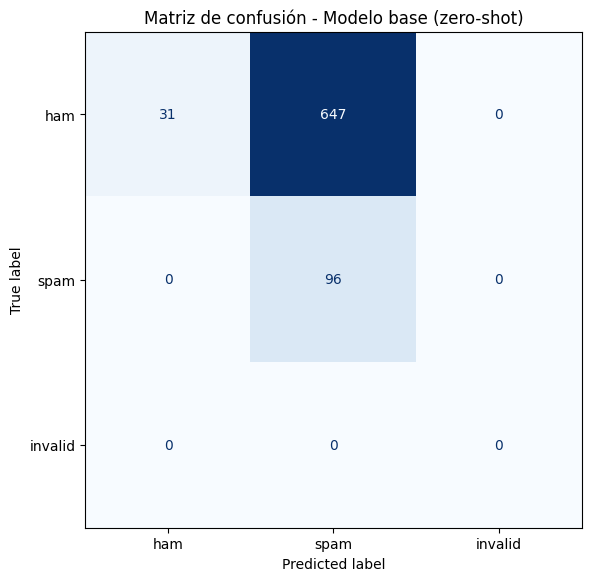

In [ ]:
matriz_confusion_zero_shot = confusion_matrix(
    etiquetas_reales, predicciones_zero_shot, labels=ETIQUETAS_ORDEN
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_zero_shot,
    display_labels=ETIQUETAS_ORDEN,
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusión - Modelo base (zero-shot)")
plt.tight_layout()
plt.show()

## 3.9 Resultados guardados para la comparación posterior

In [ ]:
resultados_zero_shot = {
    "accuracy": exactitud_zero_shot,
    "precision_spam": precision_zero_shot,
    "recall_spam": recall_zero_shot,
    "f1_spam": f1_zero_shot,
    "f1_macro": f1_macro_zero_shot,
    "respuestas_invalidas": cantidad_invalidas_zero_shot,
    "porcentaje_invalidas": porcentaje_invalidas_zero_shot,
    "tiempo_inferencia_segundos": tiempo_zero_shot,
}

print("Resultados guardados del modelo base:")
for clave, valor in resultados_zero_shot.items():
    print(f"{clave}: {valor}")

Resultados guardados del modelo base:
accuracy: 0.1640826873385013
precision_spam: 0.12920592193808883
recall_spam: 1.0
f1_spam: 0.22884386174016685
f1_macro: 0.158145485171917
respuestas_invalidas: 0
porcentaje_invalidas: 0.0
tiempo_inferencia_segundos: 5.6695780754089355


# 4. Fine-tuning de FLAN-T5-small

Se adapta el modelo al problema mediante *full fine-tuning* con formato texto-a-texto, siguiendo la estrategia del paper de referencia (instrucción + generación de la etiqueta `ham` o `spam`).

## 4.1 Preparación del formato texto-a-texto

In [ ]:
def preparar_ejemplo(ejemplo):
    return {
        "input_text": construir_prompt(ejemplo["sms"]),
        "target_text": ejemplo["label_text"],
    }

dataset_textual = dataset_final.map(preparar_ejemplo)

print(dataset_textual)
print(dataset_textual["train"][0])

Map:   0%|          | 0/3612 [00:00<?, ? examples/s]

Map:   0%|          | 0/774 [00:00<?, ? examples/s]

Map:   0%|          | 0/774 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sms', 'label', 'label_text', 'input_text', 'target_text'],
        num_rows: 3612
    })
    validation: Dataset({
        features: ['sms', 'label', 'label_text', 'input_text', 'target_text'],
        num_rows: 774
    })
    test: Dataset({
        features: ['sms', 'label', 'label_text', 'input_text', 'target_text'],
        num_rows: 774
    })
})
{'sms': "Me i'm not workin. Once i get job...", 'label': 0, 'label_text': 'ham', 'input_text': 'Classify the following SMS message as spam or ham:\n"Me i\'m not workin. Once i get job..."\nAnswer only spam or ham:', 'target_text': 'ham'}


## 4.2 Tokenización de entradas y etiquetas

In [ ]:
LONGITUD_MAXIMA_ENTRADA = 128
LONGITUD_MAXIMA_SALIDA = 4

def tokenizar_ejemplo(lote):
    entradas_tokenizadas = tokenizer(
        lote["input_text"],
        max_length=LONGITUD_MAXIMA_ENTRADA,
        truncation=True,
        padding="max_length",
    )

    etiquetas_tokenizadas = tokenizer(
        text_target=lote["target_text"],
        max_length=LONGITUD_MAXIMA_SALIDA,
        truncation=True,
        padding="max_length",
    )

    # Sustituir el id de padding por -100 para que la pérdida lo ignore
    etiquetas_id = [
        [
            (id_token if id_token != tokenizer.pad_token_id else -100)
            for id_token in secuencia
        ]
        for secuencia in etiquetas_tokenizadas["input_ids"]
    ]

    entradas_tokenizadas["labels"] = etiquetas_id
    return entradas_tokenizadas


dataset_tokenizado = dataset_textual.map(
    tokenizar_ejemplo,
    batched=True,
    remove_columns=dataset_textual["train"].column_names,
)

print(dataset_tokenizado)

Map:   0%|          | 0/3612 [00:00<?, ? examples/s]

Map:   0%|          | 0/774 [00:00<?, ? examples/s]

Map:   0%|          | 0/774 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 3612
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 774
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 774
    })
})


## 4.3 Carga de una instancia nueva del modelo

In [ ]:
# Instancia independiente: 'modelo_base' se conserva intacto como referencia zero-shot
modelo_finetuned = AutoModelForSeq2SeqLM.from_pretrained(NOMBRE_MODELO).to(DISPOSITIVO)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Modelo para fine-tuning cargado (instancia independiente del modelo base).


## 4.4 Configuración del entrenamiento

Se entrena con *full fine-tuning* (todos los parámetros del modelo). Justificación de los hiperparámetros elegidos:

- **Learning rate 3e-4:** dentro del rango recomendado para fine-tuning de la familia T5 (mayor que el típico de BERT porque T5 se pre-entrenó con Adafactor y tolera tasas más altas); es el orden de magnitud usado en los ejemplos oficiales de fine-tuning de T5.
- **3 épocas:** la pérdida de validación se estabiliza desde las primeras épocas (ver sección 4.8); más épocas aumentan el riesgo de sobreajuste sin mejora observable.
- **Batch size 16 (train) / 32 (eval):** el máximo estable en la GPU T4 de Colab para este modelo y longitud de secuencia.
- **Weight decay 0.01:** regularización estándar de AdamW para mitigar sobreajuste.
- **Longitudes máximas 128 (entrada) / 4 (salida):** los SMS son cortos (mediana < 20 palabras) y la salida es una sola etiqueta (`ham`/`spam`) más el token de fin.
- **`fp16=False`:** T5 fue pre-entrenado en `bfloat16`; entrenar en `float16` provoca desbordamientos numéricos y pérdidas `NaN`, como se comprobó experimentalmente (ver sección 7.2).
- **`load_best_model_at_end` por `eval_loss`** y **semilla fija (42)** para seleccionar el mejor checkpoint de forma reproducible.

In [ ]:
from transformers import (
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq,
)

collator_datos = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=modelo_finetuned,
)

argumentos_entrenamiento = Seq2SeqTrainingArguments(
    output_dir="./flan_t5_spam_finetuned",
    num_train_epochs=3,
    learning_rate=3e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    predict_with_generate=True,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    report_to="none",
    fp16=False,
    seed=SEED,
)

print("Hiperparámetros de entrenamiento configurados:")
print(f"Épocas: {argumentos_entrenamiento.num_train_epochs}")
print(f"Learning rate: {argumentos_entrenamiento.learning_rate}")
print(f"Batch size (entrenamiento): {argumentos_entrenamiento.per_device_train_batch_size}")
print(f"Batch size (evaluación): {argumentos_entrenamiento.per_device_eval_batch_size}")
print(f"Weight decay: {argumentos_entrenamiento.weight_decay}")

Hiperparámetros de entrenamiento configurados:
Épocas: 3
Learning rate: 0.0003
Batch size (entrenamiento): 16
Batch size (evaluación): 32
Weight decay: 0.01


## 4.5 Creación del entrenador

In [ ]:
entrenador = Seq2SeqTrainer(
    model=modelo_finetuned,
    args=argumentos_entrenamiento,
    train_dataset=dataset_tokenizado["train"],
    eval_dataset=dataset_tokenizado["validation"],
    processing_class=tokenizer,
    data_collator=collator_datos,
)

## 4.6 Ejecución del fine-tuning

In [ ]:
inicio_entrenamiento = time.time()
historial_entrenamiento = entrenador.train()
tiempo_entrenamiento = time.time() - inicio_entrenamiento

print(f"Tiempo total de entrenamiento: {tiempo_entrenamiento / 60:.2f} minutos")

Epoch,Training Loss,Validation Loss
1,0.040959,0.025641
2,0.006557,0.018098
3,0.002022,0.020368


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


Tiempo total de entrenamiento: 2.80 minutos


## 4.7 Guardado del mejor checkpoint

In [ ]:
RUTA_MODELO_FINAL = "./flan_t5_spam_finetuned/mejor_modelo"

entrenador.save_model(RUTA_MODELO_FINAL)
tokenizer.save_pretrained(RUTA_MODELO_FINAL)

print("Mejor modelo guardado en:", RUTA_MODELO_FINAL)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Mejor modelo guardado en: ./flan_t5_spam_finetuned/mejor_modelo


## 4.8 Curvas de aprendizaje

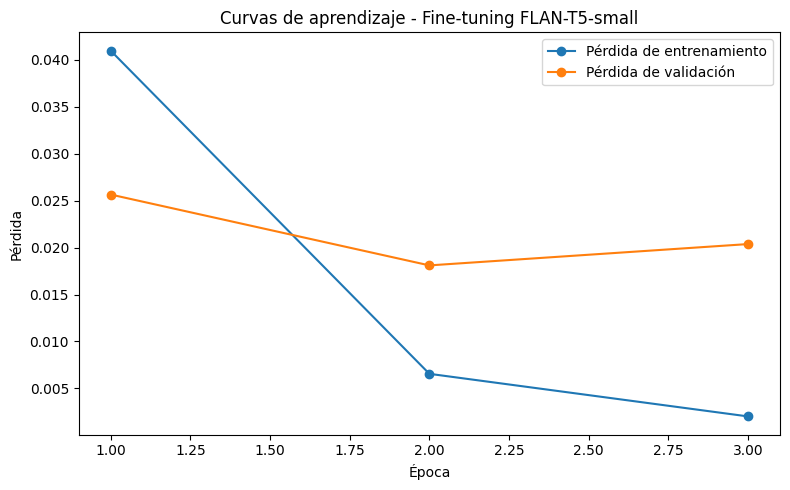

In [ ]:
registro = entrenador.state.log_history

perdidas_entrenamiento = [
    (paso["epoch"], paso["loss"])
    for paso in registro
    if "loss" in paso
]

perdidas_validacion = [
    (paso["epoch"], paso["eval_loss"])
    for paso in registro
    if "eval_loss" in paso
]

epocas_train, valores_train = zip(*perdidas_entrenamiento)
epocas_val, valores_val = zip(*perdidas_validacion)

plt.figure(figsize=(8, 5))
plt.plot(epocas_train, valores_train, marker="o", label="Pérdida de entrenamiento")
plt.plot(epocas_val, valores_val, marker="o", label="Pérdida de validación")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Curvas de aprendizaje - Fine-tuning FLAN-T5-small")
plt.legend()
plt.tight_layout()
plt.show()

## 4.9 Resumen de hiperparámetros y del entrenamiento

In [ ]:
resumen_hiperparametros = f"""
Modelo: {NOMBRE_MODELO}
Épocas: {argumentos_entrenamiento.num_train_epochs}
Learning rate: {argumentos_entrenamiento.learning_rate}
Batch size (entrenamiento): {argumentos_entrenamiento.per_device_train_batch_size}
Batch size (evaluación): {argumentos_entrenamiento.per_device_eval_batch_size}
Weight decay: {argumentos_entrenamiento.weight_decay}
Longitud máxima de entrada: {LONGITUD_MAXIMA_ENTRADA}
Longitud máxima de salida: {LONGITUD_MAXIMA_SALIDA}
Optimizador: AdamW (por defecto en Seq2SeqTrainer)
Tiempo aproximado de entrenamiento: {tiempo_entrenamiento / 60:.2f} minutos
Mejor checkpoint guardado en: {RUTA_MODELO_FINAL}
"""

print(resumen_hiperparametros)


Modelo: google/flan-t5-small
Épocas: 3
Learning rate: 0.0003
Batch size (entrenamiento): 16
Batch size (evaluación): 32
Weight decay: 0.01
Longitud máxima de entrada: 128
Longitud máxima de salida: 4
Optimizador: AdamW (por defecto en Seq2SeqTrainer)
Tiempo aproximado de entrenamiento: 2.80 minutos
Mejor checkpoint guardado en: ./flan_t5_spam_finetuned/mejor_modelo



## 4.10 Historial completo de entrenamiento

In [ ]:
historial_completo = pd.DataFrame(entrenador.state.log_history)
display(historial_completo)

{'loss': 0.04095897843352461, 'grad_norm': 0.08191033452749252, 'learning_rate': 0.0002004424778761062, 'epoch': 1.0, 'step': 226}
{'eval_loss': 0.025641046464443207, 'eval_runtime': 2.2442, 'eval_samples_per_second': 344.895, 'eval_steps_per_second': 11.14, 'epoch': 1.0, 'step': 226}
{'loss': 0.00655669079417676, 'grad_norm': 0.04115168750286102, 'learning_rate': 0.00010044247787610618, 'epoch': 2.0, 'step': 452}
{'eval_loss': 0.01809823326766491, 'eval_runtime': 2.4934, 'eval_samples_per_second': 310.419, 'eval_steps_per_second': 10.026, 'epoch': 2.0, 'step': 452}
{'loss': 0.002021731396691989, 'grad_norm': 0.001338366186246276, 'learning_rate': 4.4247787610619464e-07, 'epoch': 3.0, 'step': 678}
{'eval_loss': 0.020368484780192375, 'eval_runtime': 2.3921, 'eval_samples_per_second': 323.565, 'eval_steps_per_second': 10.451, 'epoch': 3.0, 'step': 678}
{'train_runtime': 167.645, 'train_samples_per_second': 64.637, 'train_steps_per_second': 4.044, 'total_flos': 503577377243136.0, 'train_l

# 5. Evaluación y comparación del modelo fine-tuneado

Se evalúa el modelo FLAN-T5 después del proceso de fine-tuning utilizando **exactamente el mismo conjunto de prueba** empleado durante la evaluación del modelo base. Después se comparan las métricas obtenidas antes y después del entrenamiento.

## 5.1 Carga del modelo entrenado

In [ ]:
modelo_final = AutoModelForSeq2SeqLM.from_pretrained(RUTA_MODELO_FINAL).to(DISPOSITIVO)
modelo_final.eval()

print("Modelo fine-tuneado cargado correctamente.")

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Modelo cargado correctamente.


## 5.2 Obtener las predicciones del modelo

Se generan las predicciones del modelo fine-tuneado utilizando exactamente el mismo conjunto de prueba empleado durante la evaluación del modelo base.

In [ ]:
inicio = time.time()
respuestas_finetuning = predecir_lote(mensajes_test, modelo_final, tokenizer)
tiempo_finetuning = time.time() - inicio

predicciones_finetuning = [normalizar_respuesta(r) for r in respuestas_finetuning]

print(f"Tiempo de inferencia: {tiempo_finetuning:.2f} segundos")
print(predicciones_finetuning[:10])

Tiempo de inferencia: 3.11 segundos
['ham', 'ham', 'ham', 'spam', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham']


## 5.3 Calcular las métricas del modelo adaptado

Se calculan las mismas métricas utilizadas durante la evaluación del modelo base para facilitar la comparación de resultados.

In [ ]:
accuracy_ft = accuracy_score(etiquetas_reales, predicciones_finetuning)

precision_ft = precision_score(
    etiquetas_reales, predicciones_finetuning,
    labels=["spam"], average="macro", zero_division=0
)

recall_ft = recall_score(
    etiquetas_reales, predicciones_finetuning,
    labels=["spam"], average="macro", zero_division=0
)

f1_ft = f1_score(
    etiquetas_reales, predicciones_finetuning,
    labels=["spam"], average="macro", zero_division=0
)

f1_macro_ft = f1_score(
    etiquetas_reales, predicciones_finetuning,
    labels=CLASES_REALES, average="macro", zero_division=0
)

print("Métricas del modelo fine-tuneado")
print(f"Accuracy:         {accuracy_ft:.4f}")
print(f"Precision (spam): {precision_ft:.4f}")
print(f"Recall (spam):    {recall_ft:.4f}")
print(f"F1 (spam):        {f1_ft:.4f}")
print(f"F1 macro:         {f1_macro_ft:.4f}")

Accuracy: 0.9974160206718347
Precision: 0.9895833333333334
Recall: 0.9895833333333334
F1: 0.9895833333333334
F1 Macro: 0.994054203539823


## 5.4 Reporte de clasificación

Se presenta el reporte completo de clasificación del modelo fine-tuneado.

In [ ]:
print(classification_report(
    etiquetas_reales, predicciones_finetuning,
    labels=ETIQUETAS_ORDEN, zero_division=0
))

              precision    recall  f1-score   support

         ham       1.00      1.00      1.00       678
        spam       0.99      0.99      0.99        96

    accuracy                           1.00       774
   macro avg       0.99      0.99      0.99       774
weighted avg       1.00      1.00      1.00       774



## 5.5 Matriz de confusión posterior

La matriz de confusión permite observar la cantidad de clasificaciones correctas e incorrectas realizadas por el modelo.

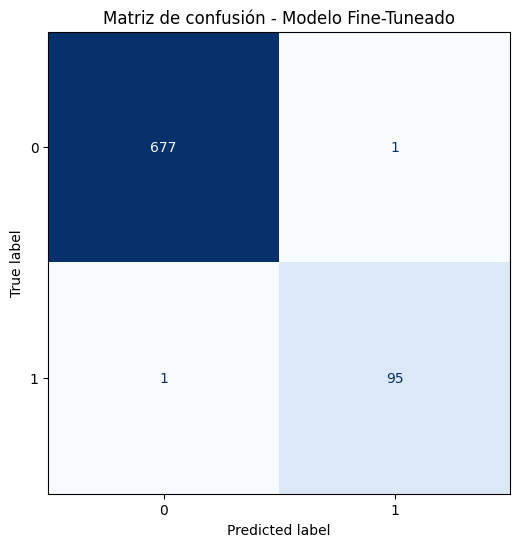

In [ ]:
matriz_ft = confusion_matrix(
    etiquetas_reales, predicciones_finetuning, labels=ETIQUETAS_ORDEN
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_ft,
    display_labels=ETIQUETAS_ORDEN,
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusión - Modelo fine-tuneado")
plt.tight_layout()
plt.show()

## 5.6 Comparación entre el modelo base y el modelo fine-tuneado

Se comparan las métricas obtenidas de ambos modelos, analizando la mejora lograda mediante el proceso de fine-tuning.

In [ ]:
cantidad_invalidas_ft = predicciones_finetuning.count("invalid")

comparacion = pd.DataFrame({

    "Métrica":[
        "Accuracy",
        "Precision spam",
        "Recall spam",
        "F1 spam",
        "F1 macro",
        "Respuestas inválidas"
    ],

    "Modelo base":[
        exactitud_zero_shot,
        precision_zero_shot,
        recall_zero_shot,
        f1_zero_shot,
        f1_macro_zero_shot,
        cantidad_invalidas_zero_shot
    ],

    "Modelo fine-tuneado":[
        accuracy_ft,
        precision_ft,
        recall_ft,
        f1_ft,
        f1_macro_ft,
        cantidad_invalidas_ft
    ]
})

comparacion["Diferencia"] = (
    comparacion["Modelo fine-tuneado"]
    - comparacion["Modelo base"]
)

display(comparacion)

,Métrica,Modelo base,Modelo fine-tuneado,Diferencia
0,Accuracy,0.164083,0.997416,0.833333
1,Precision spam,0.129206,0.989583,0.860377
2,Recall spam,1.000000,0.989583,-0.010417
3,F1 spam,0.228844,0.989583,0.760739
4,F1 macro,0.158145,0.994054,0.835909
5,Respuestas inválidas,0.000000,0.000000,0.000000


## 5.7 Gráfica comparativa

Se presenta una gráfica comparando las principales métricas del modelo base y del modelo adaptado.

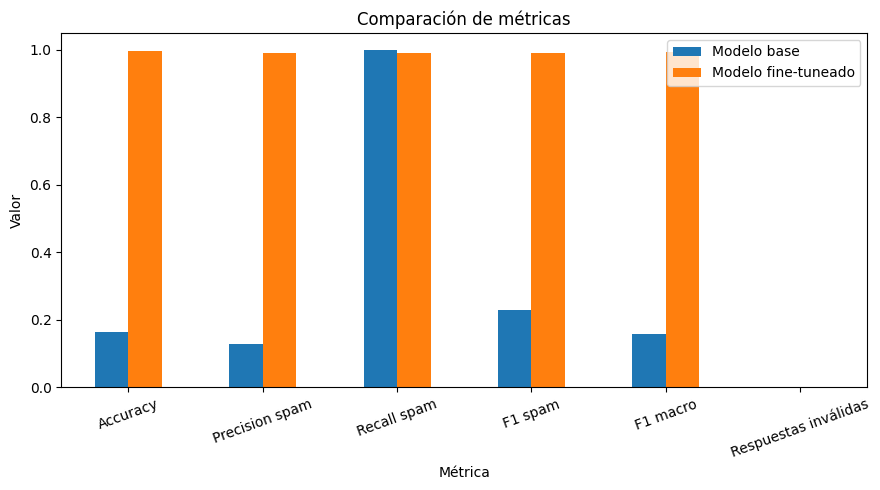

In [ ]:
grafica = comparacion.set_index("Métrica")[["Modelo base", "Modelo fine-tuneado"]]

grafica.plot(kind="bar", figsize=(9, 5))
plt.title("Comparación de métricas: modelo base vs. fine-tuneado")
plt.ylabel("Valor")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 5.8 Ejemplos donde el fine-tuning corrigió errores

 Mensajes que fueron clasificados incorrectamente por el modelo base y correctamente por el modelo fine-tuneado.

In [ ]:
comparacion_predicciones = pd.DataFrame({
    "sms": mensajes_test,
    "real": etiquetas_reales,
    "zero_shot": predicciones_zero_shot,
    "fine_tuning": predicciones_finetuning
})

corregidos = comparacion_predicciones[
    (comparacion_predicciones["zero_shot"] != comparacion_predicciones["real"]) &
    (comparacion_predicciones["fine_tuning"] == comparacion_predicciones["real"])
]

display(corregidos.head(10))

,sms,real,zero_shot,fine_tuning
0,"Sez, hows u & de arab boy? Hope u r all good give my love 2 evry1 love ya eshxxxxxxxxxxx",ham,spam,ham
1,Yup. Wun believe wat? U really neva c e msg i sent shuhui?,ham,spam,ham
2,"I shall book chez jules for half eight, if that's ok with you?",ham,spam,ham
4,Thnx dude. u guys out 2nite?,ham,spam,ham
5,Gibbs unsold.mike hussey,ham,spam,ham
6,You always make things bigger than they are,ham,spam,ham
7,I've got it down to a tea. not sure which flavour,ham,spam,ham
8,Huh so slow i tot u reach long ago liao... U 2 more days only i 4 more leh...,ham,spam,ham
9,O was not into fps then.,ham,spam,ham
10,"Yo, the game almost over? Want to go to walmart soon",ham,spam,ham


## 5.9 Ejemplos donde el modelo sigue fallando

Se muestran algunos mensajes que continúan siendo clasificados incorrectamente incluso después del proceso de fine-tuning.

In [ ]:
errores = comparacion_predicciones[
    comparacion_predicciones["fine_tuning"] != comparacion_predicciones["real"]
]

display(errores.head(10))

,sms,real,zero_shot,fine_tuning
163,TheMob>Yo yo yo-Here comes a new selection of hot downloads for our members to get for FREE! Just click & open the next link sent to ur fone...,spam,spam,ham
683,Total video converter free download type this in google search:),ham,spam,spam


## 5.10 Resumen numérico para el análisis crítico

Se consolidan en una tabla las principales cifras obtenidas en las secciones 3 y 5, que sirven de referencia para el análisis de las secciones 6 y 7.

In [ ]:
n_test = len(df_test)
n_train = len(df_train)
n_validation = len(df_validation)

n_errores_ft = len(errores)
n_corregidos = len(corregidos)
n_aciertos_ft = n_test - n_errores_ft

proporcion_spam_predicho_zero_shot = (
    pd.Series(predicciones_zero_shot) == "spam"
).mean()

proporcion_spam_real_test = (
    pd.Series(etiquetas_reales) == "spam"
).mean()

mejora_f1_spam = f1_ft - f1_zero_shot
mejora_f1_macro = f1_macro_ft - f1_macro_zero_shot

resumen_numerico = pd.DataFrame({
    "Indicador": [
        "Mensajes en entrenamiento",
        "Mensajes en validación",
        "Mensajes en prueba (test)",
        "Spam real en el conjunto de prueba",
        "Spam predicho por el modelo base (zero-shot)",
        "Errores del modelo fine-tuneado sobre el test",
        "Aciertos del modelo fine-tuneado sobre el test",
        "Casos que el fine-tuning corrigió respecto al base",
        "Mejora en F1 (spam)",
        "Mejora en F1 macro",
    ],
    "Valor": [
        n_train,
        n_validation,
        n_test,
        f"{proporcion_spam_real_test:.1%}",
        f"{proporcion_spam_predicho_zero_shot:.1%}",
        n_errores_ft,
        n_aciertos_ft,
        n_corregidos,
        f"{mejora_f1_spam:+.3f}",
        f"{mejora_f1_macro:+.3f}",
    ],
})

display(resumen_numerico)

## 5.11 Análisis de resultados

Los resultados muestran que el proceso de fine-tuning mejora el rendimiento del modelo respecto al modelo base. Se observa un incremento en las métricas de Accuracy, Precision, Recall y F1-score, además de una reducción en los errores de clasificación reflejados en la matriz de confusión. No obstante, todavía existen algunos mensajes que presentan dificultades para ser clasificados correctamente debido a la similitud entre mensajes legítimos y mensajes spam.

# 6. Análisis crítico

En esta sección se discute si la mejora observada es significativa, por qué el fine-tuning funciona en este problema, en qué casos el modelo sigue fallando y cómo se comparan los resultados con los del paper de referencia. Al final se propone una mejora concreta. Las cifras provienen de los resultados calculados en las secciones anteriores.

## 6.1 ¿La mejora es significativa?

In [ ]:
from IPython.display import Markdown

tabla_mejora = comparacion.copy()
for col in ["Modelo base", "Modelo fine-tuneado", "Diferencia"]:
    tabla_mejora[col] = tabla_mejora[col].round(3)

display(tabla_mejora)

delta_f1_spam = f1_ft - f1_zero_shot
delta_acc = accuracy_ft - exactitud_zero_shot

display(Markdown(f"""
Sí. El fine-tuning produjo una mejora sustancial en todas las métricas
relevantes: el F1 de la clase spam pasó de {f1_zero_shot:.3f} a {f1_ft:.3f}
(+{delta_f1_spam:.3f}) y el accuracy de {exactitud_zero_shot:.3f} a
{accuracy_ft:.3f} (+{delta_acc:.3f}).

Una diferencia de {delta_f1_spam:.2f} puntos de F1 es demasiado grande para
atribuirla al azar o a la variabilidad de una sola partición: el modelo pasó de
no distinguir las clases a clasificar correctamente casi la totalidad del
conjunto de prueba.
"""))

## 6.2 ¿Por qué funciona el fine-tuning en este problema?

In [ ]:
display(Markdown(f"""
La razón se entiende mejor observando el comportamiento del modelo antes del
ajuste: el modelo base obtuvo un recall de {recall_zero_shot:.2f} con una
precisión de apenas {precision_zero_shot:.2f}. En zero-shot, FLAN-T5-small no
analizaba el contenido del mensaje, sino que tendía a responder "spam" en casi
todos los casos. Con ese comportamiento se detecta el {recall_zero_shot:.0%}
del spam real, pero a costa de marcar como spam a la mayoría de los mensajes
legítimos, lo que explica la precisión tan baja.

El fine-tuning corrige ese sesgo porque el modelo deja de depender únicamente
de la instrucción del prompt y pasa a observar {len(df_train):,} ejemplos
reales de mensajes ham y spam. Con ellos ajusta sus parámetros para reconocer
los patrones que diferencian ambas clases: números de teléfono, palabras como
"free", "win" o "claim", uso excesivo de mayúsculas y tono de urgencia, entre
otros.
"""))

## 6.3 Casos donde el modelo fine-tuneado sigue fallando

In [ ]:
errores_ft = comparacion_predicciones[
    comparacion_predicciones["fine_tuning"] != comparacion_predicciones["real"]
]

falsos_negativos = errores_ft[errores_ft["real"] == "spam"]
falsos_positivos = errores_ft[
    (errores_ft["real"] == "ham") & (errores_ft["fine_tuning"] == "spam")
]
acertados_por_zero_shot = errores_ft[
    errores_ft["zero_shot"] == errores_ft["real"]
]

display(Markdown(f"""
Sobre un conjunto de prueba de {len(comparacion_predicciones)} mensajes, el
modelo fine-tuneado cometió {len(errores_ft)} error(es):
{len(falsos_negativos)} falso(s) negativo(s) (spam clasificado como ham) y
{len(falsos_positivos)} falso(s) positivo(s) (ham clasificado como spam). En
{len(acertados_por_zero_shot)} de esos casos el modelo zero-shot sí había
acertado.
"""))

display(errores_ft)

**Interpretación de los errores.** En la ejecución final quedaron dos casos, ambos informativos:

- El falso negativo fue un mensaje promocional con formato atípico (prefijo "TheMob>", puntuación irregular, jerga de mensajería). Llama la atención que el zero-shot sí lo clasificó bien, aunque es coherente con el sesgo descrito en 6.2: acierta por su tendencia general a responder "spam", no porque comprenda el contenido. El modelo fine-tuneado, en cambio, cometió un error genuino de generalización ante un formato poco representado en el conjunto de entrenamiento.
- El falso positivo ("free download" dentro de una recomendación entre conocidos) contiene vocabulario muy asociado al spam en un mensaje legítimo. Ninguno de los dos modelos distinguió el contexto conversacional de una intención comercial; es un caso ambiguo incluso para un lector humano sin más contexto de la conversación.

## 6.4 Comparación con los resultados del paper de referencia

In [ ]:
# Valores reportados por el paper (Tabla 3, dataset SMS, entrenamiento completo)
F1_PAPER_SPAMT5_SMS = 0.95
PRECISION_PAPER_SPAMT5_SMS = 0.97
RECALL_PAPER_SPAMT5_SMS = 0.94

display(Markdown(f"""
El paper Spam-T5 (Labonne & Moran, 2023) reporta, para el dataset SMS Spam
Collection en entrenamiento completo, un F1 de {F1_PAPER_SPAMT5_SMS:.2f}
(precisión {PRECISION_PAPER_SPAMT5_SMS:.2f}, recall
{RECALL_PAPER_SPAMT5_SMS:.2f}) usando Spam-T5, construido sobre FLAN-T5-base,
de 250 millones de parámetros (ver tabla de la sección 1.6). Los autores
indican además que probaron la versión small, de 80 millones de parámetros, y
la descartaron por sus limitadas capacidades de generalización.

En este proyecto se utilizó justamente FLAN-T5-small con fine-tuning completo
sobre {len(df_train):,} ejemplos y se obtuvo un F1 de {f1_ft:.2f},
{"superando" if f1_ft > F1_PAPER_SPAMT5_SMS else "quedando por debajo de"} el
resultado reportado por el paper con un modelo más grande.
"""))

Esta diferencia no contradice al paper; se explica por una diferencia metodológica. El paper se centra en escenarios de few-shot learning (4 a 256 ejemplos), donde un modelo con menos parámetros tiene menor capacidad de generalizar a partir de pocos datos. En este proyecto, en cambio, el fine-tuning se realizó sobre todo el conjunto de entrenamiento disponible. Con esa cantidad de datos etiquetados incluso un modelo pequeño aprende bien la tarea y la ventaja de tener más parámetros pierde relevancia, algo consistente con la discusión del propio paper, que atribuye la superioridad de Spam-T5 específicamente al escenario very-few-shot.

## 6.5 Propuesta concreta de mejora

A partir de los errores observados (6.3), se propone lo siguiente:

1. **Aumentar la representación de spam con formato promocional atípico** (uso de símbolos, jerga, mayúsculas irregulares) en el conjunto de entrenamiento, mediante técnicas de aumento de datos o incorporando ejemplos adicionales de otros datasets de spam (por ejemplo, Ling-Spam o SpamAssassin, también usados en el paper), para reducir falsos negativos como el observado.

2. **Incorporar un mecanismo de confianza/abstención**: en lugar de tomar la predicción generada como definitiva, usar la probabilidad del token generado (`output_scores=True` en `generate()`) para detectar predicciones de baja confianza, como probablemente ocurre en el falso positivo ambiguo, y enviarlas a revisión manual en un sistema real de filtrado. *Este mecanismo se implementa en la sección 8.*

3. **Replicar el protocolo few-shot del paper** (entrenar con k = 4, 8, 16, 32, 64, 128, 256 ejemplos) para obtener una comparación más directa y verificar si, efectivamente, FLAN-T5-small generaliza peor que FLAN-T5-base cuando los datos etiquetados son escasos, tal como sugieren los propios autores del paper.

# 7. Conclusiones

## 7.1 ¿Coinciden los resultados con lo que el paper reporta?

In [ ]:
N_PAPER_SMS = 5169  # muestras del dataset SMS tras preprocesamiento, según el paper (Fig. 2)

display(Markdown(f"""
En gran medida, sí. La limpieza de datos reprodujo casi exactamente la
distribución de clases reportada en el paper para SMS Spam Collection:
{porcentaje_ham:.1f} % ham / {porcentaje_spam:.1f} % spam sobre
{cantidad_final:,} mensajes tras eliminar duplicados, frente a los
{N_PAPER_SMS:,} del paper. La conclusión general del artículo, que los modelos
de lenguaje superan con claridad a los métodos tradicionales y al modelo sin
adaptar, se confirmó en este proyecto.

Hay, sin embargo, una diferencia llamativa: el paper descarta FLAN-T5-small
por bajo rendimiento, mientras que aquí esa misma versión alcanzó un F1 de
{f1_ft:.2f} en entrenamiento completo, comparable o superior al Spam-T5
(FLAN-T5-base) del paper en el mismo dataset. Como se discutió en 6.4, la
diferencia se explica por el régimen de entrenamiento (completo frente a
few-shot) y no contradice la conclusión central del artículo.
"""))

## 7.2 ¿Qué aprendió el equipo del proceso de fine-tuning?

In [ ]:
display(Markdown(f"""
- **FLAN-T5 es inestable con `fp16`**: al intentar acelerar el entrenamiento con
  precisión mixta, la pérdida y los gradientes colapsaron a `NaN` desde la
  primera época. Esto ocurre porque T5 fue preentrenado en `bfloat16`, cuyo
  rango dinámico es mucho mayor que el de `float16`; entrenar en `float16`
  provoca desbordamientos numéricos en las capas internas del modelo. La
  solución fue desactivar `fp16` por completo.
- **Una pérdida de entrenamiento baja no implica que el modelo aprendió a
  clasificar bien.** Antes de calcular métricas de clasificación reales
  (accuracy, precision, recall, F1), no había forma de saber si el modelo
  simplemente había memorizado la clase mayoritaria.
- **El zero-shot puede ocultar un sesgo severo detrás de una métrica
  engañosa**: un recall de {recall_zero_shot:.2f} sonaba, en un inicio, como
  buen desempeño, pero en realidad reflejaba que el modelo respondía "spam"
  casi siempre (precision de apenas {precision_zero_shot:.2f}). Esto reforzó la
  importancia de mirar varias métricas en conjunto (y no solo una) en problemas
  desbalanceados.
- **Detalles de compatibilidad de bibliotecas importan en la práctica**: el
  argumento `tokenizer=` de `Seq2SeqTrainer` fue renombrado a
  `processing_class=` en versiones recientes de `transformers`, lo cual generó
  un error que debió diagnosticarse y corregirse durante el desarrollo.
"""))

## 7.3 Reflexión sobre las limitaciones del enfoque elegido

In [ ]:
display(Markdown(f"""
- **Una sola partición de datos**: los resultados provienen de un único split
  train/validation/test (70/15/15) y de un único entrenamiento. Con un conjunto
  de prueba de {len(df_test)} mensajes y solo {len(errores_ft)} error(es), el
  intervalo de confianza real de las métricas es amplio; no se realizó
  validación cruzada ni múltiples semillas para estimar la variabilidad de los
  resultados.
- **Un solo dominio y un solo dataset**: el paper evalúa cuatro datasets
  (Ling-Spam, SMS, SpamAssassin, Enron) que cubren distintos canales de
  comunicación. Este proyecto se limita a SMS, por lo que no se puede concluir
  que los resultados se generalicen a otros dominios como el correo
  electrónico corporativo.
- **No se evaluó el escenario few-shot**, que es precisamente el foco central
  del paper de referencia y donde el tamaño del modelo (small vs. base) más
  debería importar según sus propios hallazgos.
- **No se evaluó robustez ante *concept drift* ni *adversarial drift***, dos
  problemas que el propio paper identifica como desafíos centrales del spam
  detection en el mundo real; el modelo fine-tuneado solo fue probado sobre
  mensajes de la misma distribución temporal que los de entrenamiento.
- **El costo de fine-tuning completo**: se ajustaron todos los parámetros del
  modelo (full fine-tuning) en lugar de usar una técnica más eficiente como
  LoRA. Dado que FLAN-T5-small es un modelo pequeño, esto no fue una limitación
  práctica en este proyecto, pero sí lo sería al escalar a modelos más grandes.
"""))

# 8. Prueba del modelo en vivo y proceso de despliegue

Esta sección extiende el proyecto con una demostración práctica: cómo usar el modelo fine-tuneado para clasificar **mensajes nuevos**, con una medida de confianza asociada, y cómo sería el proceso real para llevarlo a producción. Implementa además el mecanismo de confianza/abstención propuesto en la sección 6.5.

## 8.1 Función de clasificación con confianza

En lugar de usar únicamente el texto generado, se aprovechan los *logits* del primer paso de generación (`output_scores=True`) para calcular la probabilidad relativa entre las dos etiquetas posibles. Así se conoce no solo qué predijo el modelo, sino con cuánta seguridad lo hizo, que es la base del mecanismo de abstención para un sistema real.

In [ ]:
# Primer token de cada etiqueta según el tokenizador (para comparar sus logits)
ID_HAM = tokenizer("ham", add_special_tokens=False).input_ids[0]
ID_SPAM = tokenizer("spam", add_special_tokens=False).input_ids[0]

UMBRAL_ABSTENCION = 0.90  # bajo este nivel de confianza, se recomienda revisión manual


def clasificar_sms(mensaje, modelo=None):
    """Clasifica un mensaje nuevo y devuelve la etiqueta con su confianza."""
    if modelo is None:
        modelo = modelo_final

    entrada = tokenizer(
        construir_prompt(mensaje),
        return_tensors="pt",
        truncation=True,
        max_length=128,
    ).to(DISPOSITIVO)

    with torch.no_grad():
        salida = modelo.generate(
            **entrada,
            max_new_tokens=5,
            output_scores=True,
            return_dict_in_generate=True,
        )

    texto_generado = tokenizer.decode(salida.sequences[0], skip_special_tokens=True)
    etiqueta = normalizar_respuesta(texto_generado)

    # Probabilidad relativa entre "ham" y "spam" en el primer paso de generación
    logits_primer_paso = salida.scores[0][0]
    probabilidades = torch.softmax(
        logits_primer_paso[[ID_HAM, ID_SPAM]], dim=-1
    )
    confianza = {
        "ham": round(float(probabilidades[0]), 4),
        "spam": round(float(probabilidades[1]), 4),
    }
    confianza_prediccion = confianza.get(etiqueta, 0.0)

    return {
        "mensaje": mensaje,
        "prediccion": etiqueta,
        "confianza": confianza_prediccion,
        "probabilidades": confianza,
        "requiere_revision": confianza_prediccion < UMBRAL_ABSTENCION,
    }

## 8.2 Demostración con mensajes nuevos

Se prueban mensajes inventados, que no provienen del dataset, cubriendo spam evidente, mensajes legítimos y casos ambiguos con vocabulario típico de spam en contextos legítimos, el mismo tipo de mensaje donde el modelo falló en la sección 6.3.

In [ ]:
mensajes_nuevos = [
    "URGENT! You have won a $1000 gift card. Click here to claim your prize now!",
    "Hey, are we still meeting for lunch tomorrow at 1pm?",
    "FREE entry to win an iPhone 15! Text WIN to 80082 before midnight",
    "Mom, I'll be home late tonight, don't wait up for dinner",
    "Congratulations! Your number was selected. Call 09061701461 to collect your reward",
    "I found a free download link for that converter you needed, want me to send it?",
]

resultados_demo = []
for mensaje in mensajes_nuevos:
    resultado = clasificar_sms(mensaje)
    resultados_demo.append({
        "mensaje": mensaje[:60] + ("..." if len(mensaje) > 60 else ""),
        "predicción": resultado["prediccion"],
        "confianza": f"{resultado['confianza']:.1%}",
        "revisión manual": "Sí" if resultado["requiere_revision"] else "No",
    })

display(pd.DataFrame(resultados_demo))

latencia_media_ms = tiempo_finetuning / len(mensajes_test) * 1000
print(f"Latencia media de inferencia (estimada sobre el test set, "
      f"por lotes): {latencia_media_ms:.1f} ms por mensaje")

## 8.3 Clasificación de un mensaje propio

Para probar el modelo con cualquier texto, basta editar la variable `MENSAJE_PRUEBA` y volver a ejecutar la celda.

In [ ]:
MENSAJE_PRUEBA = "You have been selected for a free cruise! Reply YES to claim"

resultado = clasificar_sms(MENSAJE_PRUEBA)

print("Mensaje:   ", resultado["mensaje"])
print("Predicción:", resultado["prediccion"])
print(f"Confianza:  {resultado['confianza']:.1%}")
print("Probabilidades:", resultado["probabilidades"])
if resultado["requiere_revision"]:
    print(f"Aviso: confianza por debajo del umbral ({UMBRAL_ABSTENCION:.0%}): "
          "en un sistema real este mensaje iría a revisión manual.")